# Volatility Forecasting and Tail-Risk Backtesting

This notebook covers the risk-*measurement* half of the toolkit: forecasting
conditional volatility with a rolling GJR-GARCH(1,1)-t model, turning those
forecasts into Value-at-Risk and Expected Shortfall, backtesting the VaR for
correct coverage and independence, and finally evaluating the volatility
forecast *itself*.

**Conventions used throughout:** volatility is annualised with 252 trading
days; VaR/ES are expressed as left-tail returns (so they are negative).

> Fitting the rolling GARCH on ten years of three assets takes a couple of
> minutes — the model is re-estimated periodically across the whole history.

In [17]:
import numpy as np
import pandas as pd

from garch_risk.data import load_returns
from garch_risk.volatility import rolling_garch_forecasts, realised_volatility
from garch_risk.var_es import rolling_var_es, backtest_var
from garch_risk.volatility_eval import evaluate_volatility_forecast
from garch_risk import plots

WINDOW, REFIT = 365, 21

## 1. Data

The universe is the S&P 500, the NASDAQ Composite, and Bitcoin — two equity
indices and one crypto asset, chosen so the models are stressed across very
different tail behaviour. Prices are downloaded from Yahoo Finance and reduced
to daily log returns.

BTC trades seven days a week while the equities do not, so the series are
aligned to the **equity trading calendar** (BTC's weekend bars are dropped).
This is a deliberate simplification: it keeps the assets on one calendar at the
cost of not capturing BTC's weekend gap risk.

In [18]:
rets = load_returns(lookback_years=10, strip_weekends=True)
print(f"{rets.shape[0]} days, {rets.index.min().date()} to {rets.index.max().date()}")
rets.tail()

2511 days, 2016-06-22 to 2026-06-18


Ticker,S&P500,NASDAQ,BTC-USD
Date,,,
2026-06-11,0.017367,0.025116,0.033789
2026-06-12,0.005013,0.003063,-0.000281
2026-06-15,0.016393,0.030250,0.042312
2026-06-16,-0.005700,-0.011594,-0.010446
2026-06-18,-0.001435,0.005354,-0.042095


In [19]:
# Sample annualised volatility -- a first sanity check on the data.
(rets.std() * np.sqrt(252) * 100).round(1)

Ticker
S&P500     18.2
NASDAQ     22.1
BTC-USD    66.8
dtype: float64

Equities should sit around 15-25% annualised and BTC several times higher.
If those numbers look wrong, the data or the scaling is wrong and nothing
downstream can be trusted.

## 2. Volatility forecasting: rolling GJR-GARCH(1,1)-t

The model is fit on a trailing window and produces a one-step-ahead volatility
forecast for each day. Three choices worth stating:

- **GJR (the asymmetry term)** captures the *leverage effect* — a negative
  shock raises tomorrow's variance more than an equal positive shock, which is
  exactly how equity volatility behaves.
- **Student-t innovations** allow fat tails in the conditional distribution.
- **Periodic refit:** parameters are re-estimated every 21 days; between refits
  they are held fixed while the variance recursion still rolls forward with each
  new return. This is the standard speed/rigour compromise.

The forecast for day *t* uses only data up to *t-1*, so the backtest later is
genuinely out-of-sample.

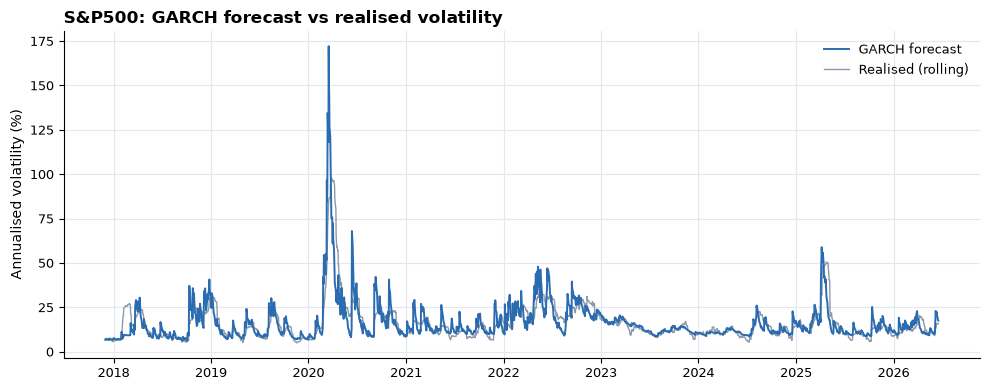

In [20]:
asset = "S&P500"
fc = rolling_garch_forecasts(rets[asset], window=WINDOW, refit_every=REFIT)
sigma, nu = fc["sigma"], fc["nu"]
realised = realised_volatility(rets[asset], window=20)

fig = plots.plot_volatility(sigma, realised=realised,
                            title=f"{asset}: GARCH forecast vs realised volatility")


### The fitted degrees of freedom tell a structural story

The Student-t degrees of freedom (`nu`) are estimated per window. Comparing
them across assets is revealing.

In [21]:
fits = {a: rolling_garch_forecasts(rets[a], window=WINDOW, refit_every=REFIT)
        for a in rets.columns}

pd.DataFrame({a: {"mean dof": fits[a]["nu"].mean(),
                  "min dof": fits[a]["nu"].min(),
                  "max dof": fits[a]["nu"].max()}
              for a in fits}).T.round(1)

,mean dof,min dof,max dof
S&P500,24.2,3.2,334.4
NASDAQ,46.6,4.2,354.0
BTC-USD,3.7,2.1,9.1


Typically the **equity** degrees of freedom come back large and unstable —
the fitted t is straining toward a normal distribution because, *once the
time-varying volatility is conditioned out*, equity standardised residuals are
close to Gaussian. In other words, GJR-GARCH absorbs almost all of equities'
unconditional fat-tailedness into the conditional volatility itself.

**BTC** is different: its degrees of freedom stay low and stable, meaning it
retains genuinely fat conditional tails even after the GARCH has removed the
volatility clustering. That contrast — equities near-Gaussian conditionally,
crypto persistently fat-tailed — is the single most informative result in the
volatility section, and it drives the VaR behaviour below.

## 3. Value-at-Risk and Expected Shortfall

For each day the one-step volatility forecast is turned into a loss
distribution by Monte Carlo, and VaR/ES are read off the left tail. The
innovation degrees of freedom are taken from the GARCH fit itself (the `nu`
series above), so the loss distribution is consistent with the volatility
model's own innovations rather than an arbitrary fixed value. No post-hoc
scaling is applied to the estimates.

Three backtests are reported:

- **Kupiec** — is the *breach rate* correct? (unconditional coverage)
- **Christoffersen independence** — are breaches *clustered*?
- **Conditional coverage** — both jointly.

S&P500 -- 95% VaR over 2146 days
  breaches      : 139 (6.48%, expected 5.00%)
  Kupiec        : p=0.0026  FAIL
  independence  : p=0.3071  PASS
  cond. coverage: p=0.0064  FAIL


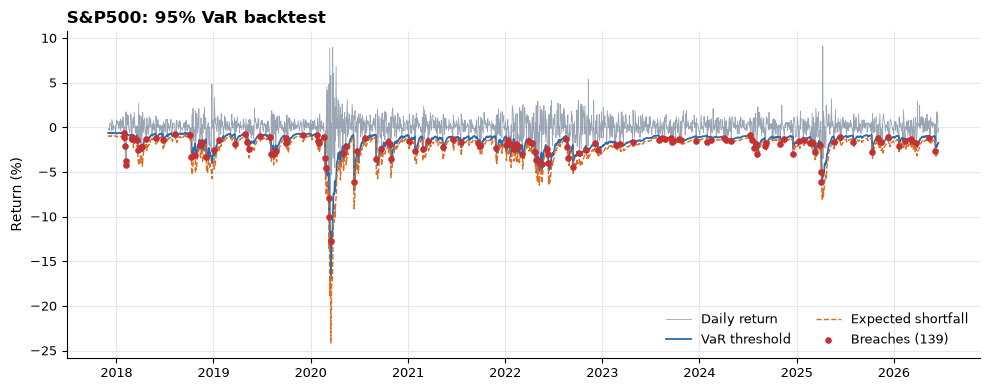

In [22]:
ve = rolling_var_es(sigma, alpha=0.05, dist="t", dof=nu, n_sims=100_000)
res = backtest_var(rets[asset], ve["VaR"], alpha=0.05)

print(f"{asset} -- 95% VaR over {res.n_obs} days")
print(f"  breaches      : {res.n_breaches} ({res.observed_rate*100:.2f}%, expected 5.00%)")
print(f"  Kupiec        : p={res.kupiec_p:.4f}  {'PASS' if res.kupiec_pass else 'FAIL'}")
print(f"  independence  : p={res.independence_p:.4f}  {'PASS' if res.independence_pass else 'FAIL'}")
print(f"  cond. coverage: p={res.cc_p:.4f}  {'PASS' if res.cc_pass else 'FAIL'}")

fig = plots.plot_var_breaches(rets[asset], ve["VaR"], ve["ES"],
                              title=f"{asset}: 95% VaR backtest")


In [23]:
# Full backtest table: every asset, 95% and 99%.
rows = []
for a in rets.columns:
    s, n = fits[a]["sigma"], fits[a]["nu"]
    for alpha in (0.05, 0.01):
        v = rolling_var_es(s, alpha=alpha, dist="t", dof=n, n_sims=100_000)
        r = backtest_var(rets[a], v["VaR"], alpha=alpha)
        rows.append({"asset": a, "level": f"{int((1-alpha)*100)}%",
                     "breach %": round(r.observed_rate*100, 2),
                     "Kupiec p": round(r.kupiec_p, 4), "Kupiec": "PASS" if r.kupiec_pass else "FAIL",
                     "indep p": round(r.independence_p, 4), "indep": "PASS" if r.independence_pass else "FAIL",
                     "CC p": round(r.cc_p, 4), "CC": "PASS" if r.cc_pass else "FAIL"})
pd.DataFrame(rows)

,asset,level,breach %,Kupiec p,Kupiec,indep p,indep,CC p,CC
0,S&P500,95%,6.48,0.0026,FAIL,0.3071,PASS,0.0064,FAIL
1,S&P500,99%,1.82,0.0006,FAIL,0.7399,PASS,0.0028,FAIL
2,NASDAQ,95%,6.24,0.0108,FAIL,0.8905,PASS,0.0383,FAIL
3,NASDAQ,99%,1.96,0.0001,FAIL,0.8466,PASS,0.0004,FAIL
4,BTC-USD,95%,5.27,0.5755,PASS,0.3975,PASS,0.5977,PASS
5,BTC-USD,99%,1.35,0.1205,PASS,0.0618,PASS,0.0524,PASS


### Reading the backtest

The independence test typically **passes across the board** — the single most
important positive result. It means breaches are not clustered: the GARCH
conditional volatility ramps up correctly around turbulent periods, so the
model's *dynamics* are sound.

BTC, with its genuinely fat fitted tails, tends to calibrate well at both
levels. The equities tend to **slightly over-breach** — more exceptions than
the nominal rate — which is a well-documented limitation of GARCH-style VaR for
equity indices. Because independence passes, this is a *level/distributional*
issue, not a dynamics one: the symmetric innovation under-weights the left tail
(equity returns are negatively skewed — crashes exceed rallies), which a
**skewed-t** innovation would address. That is recorded as future work rather
than tuned away here.

## 4. Is the volatility forecast itself any good?

A VaR backtest checks one point in the tail. But the Greeks and stress tests in
the companion notebook consume the volatility forecast *directly* — they depend
on `sigma` being a good conditional standard deviation, not on the VaR cutoff
being perfect. So the forecast is evaluated on its own terms:

- **Mincer-Zarnowitz:** regress realised variance (proxied by the squared
  return) on forecast variance. An unbiased forecast gives slope 1, intercept 0.
  Standard errors are Newey-West (HAC).
- **QLIKE:** a loss function robust to the noise in the realised proxy, used to
  rank the GARCH forecast against a naive rolling-window benchmark.

The squared-return proxy is extremely noisy, so the regression R-squared will
look low (often 0.05-0.30) **even for a good forecast** — the slope, not the
R-squared, is the informative statistic.

In [24]:
rows = []
for a in rets.columns:
    s = fits[a]["sigma"]
    bench = realised_volatility(rets[a], 20).shift(1).reindex(s.index)
    ev = evaluate_volatility_forecast(rets[a].reindex(s.index), s, benchmark_sigma=bench)
    rows.append({"asset": a,
                 "MZ slope": round(ev.mz.slope, 3),
                 "MZ intercept": f"{ev.mz.intercept:.2e}",
                 "R^2": round(ev.mz.r_squared, 3),
                 "joint p (a=0,b=1)": round(ev.mz.joint_p, 4),
                 "QLIKE GARCH": round(ev.qlike_forecast, 4),
                 "QLIKE benchmark": round(ev.qlike_benchmark, 4),
                 "GARCH wins": ev.beats_benchmark})
pd.DataFrame(rows)

,asset,MZ slope,MZ intercept,R^2,"joint p (a=0,b=1)",QLIKE GARCH,QLIKE benchmark,GARCH wins
0,S&P500,0.631,4.67e-05,0.290,0.0352,-8.2384,-8.1515,True
1,NASDAQ,0.658,6.94e-05,0.214,0.0901,-7.7402,-7.6489,True
2,BTC-USD,0.366,9.20e-04,0.019,0.0000,-5.3952,-5.1650,True


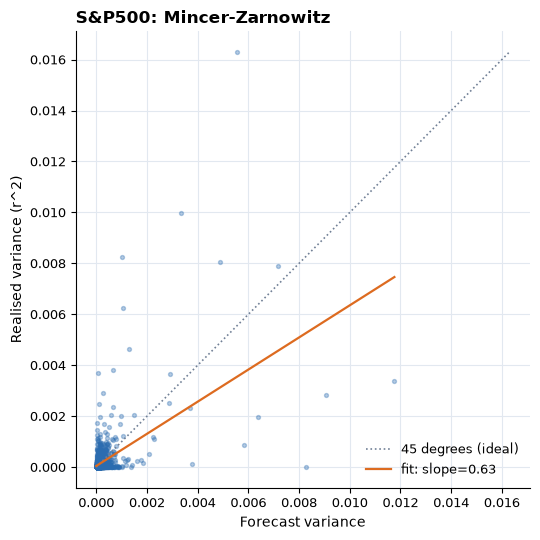

In [25]:
# Mincer-Zarnowitz scatter for the headline asset.
s = fits[asset]["sigma"]
ev = evaluate_volatility_forecast(rets[asset].reindex(s.index), s)
fig = plots.plot_mz_scatter(rets[asset].reindex(s.index)**2, s**2,
                            slope=ev.mz.slope, intercept=ev.mz.intercept,
                            title=f"{asset}: Mincer-Zarnowitz")


### Reading the forecast evaluation

The robust, clean result is **QLIKE**: the GARCH forecast beats a naive 20-day
rolling-volatility benchmark on every asset. The conditional model adds genuine
value over a simple historical estimate.

The MZ slopes typically come in **below 1**. Part of that is real — GARCH tends
to over-persist volatility after a shock — but a large part is a known artifact
of using *squared daily returns* as the realised-variance proxy: it is unbiased
but so noisy (and so outlier-driven) that the regression slope is attenuated
downward. BTC, the jumpiest asset, shows this most extremely (near-zero
R-squared). The proper remedy is intraday realised variance, which is out of
scope here and noted as future work.

**Bottom line for the Greeks arm:** the volatility forecast is a value-adding
conditional estimate — good enough to drive the option Greeks and stress tests
in the next notebook — without claiming it is a perfectly calibrated forecast.

## Summary and disclosed limitations

**What holds up:** GARCH dynamics are sound (independence passes), the fitted-dof
finding cleanly separates conditionally-Gaussian equities from fat-tailed BTC,
fitted-dof VaR calibrates BTC well, and the forecast beats a naive benchmark on
QLIKE.

**Honest limitations, disclosed rather than hidden:**

- Equity VaR slightly over-breaches; the indicated fix is a skewed-t innovation.
- BTC weekend bars are dropped (equity-calendar alignment), so weekend gap risk
  is not modelled; and no free implied-vol benchmark was available for BTC.
- The realised-variance proxy is squared daily returns; intraday realised
  variance would sharpen the Mincer-Zarnowitz evaluation.
- Model-structure choices (window, refit cadence, GARCH variant) are fixed, not
  selected by walk-forward. Walk-forward spec selection is the planned next step
  and the principled way to guard against overfitting the specification.